# EDA: Text Sentiment Analysis Dataset

Exploratory Data Analysis для датасета, собранного `DataCollectionAgent`.

**Источники:**
1. HuggingFace `rotten_tomatoes` — рецензии на фильмы
2. Web scraping `quotes.toscrape.com` — цитаты с авто-разметкой тональности

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = "../data/raw/dataset.csv"
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head(10)

Shape: (3100, 4)


,text,label,source,collected_at
0,. . . plays like somebody spliced random momen...,negative,hf_rotten_tomatoes,2026-03-26T15:12:48.645309+00:00
1,michael moore has perfected the art of highly ...,positive,hf_rotten_tomatoes,2026-03-26T15:12:48.645309+00:00
2,. . . too gory to be a comedy and too silly to...,negative,hf_rotten_tomatoes,2026-03-26T15:12:48.645309+00:00
3,"a graceful , contemplative film that gradually...",positive,hf_rotten_tomatoes,2026-03-26T15:12:48.645309+00:00
4,the fact that the 'best part' of the movie com...,negative,hf_rotten_tomatoes,2026-03-26T15:12:48.645309+00:00
5,the thriller side of this movie is falling fla...,negative,hf_rotten_tomatoes,2026-03-26T15:12:48.645309+00:00
6,more maudlin than sharp .,negative,hf_rotten_tomatoes,2026-03-26T15:12:48.645309+00:00
7,shot like a postcard and overacted with all th...,negative,hf_rotten_tomatoes,2026-03-26T15:12:48.645309+00:00
8,"oedekerk mugs mercilessly , and the genuinely ...",negative,hf_rotten_tomatoes,2026-03-26T15:12:48.645309+00:00
9,haneke keeps us at arm's length . guided more ...,negative,hf_rotten_tomatoes,2026-03-26T15:12:48.645309+00:00


## Базовая статистика

In [2]:
print("Типы данных:")
print(df.dtypes)
print(f"\nПропуски:\n{df.isnull().sum()}")
print(f"\nУникальные метки: {df['label'].unique()}")
print(f"Уникальные источники: {df['source'].unique()}")
df.describe(include="all")

Типы данных:
text            object
label           object
source          object
collected_at    object
dtype: object

Пропуски:
text            0
label           0
source          0
collected_at    0
dtype: int64

Уникальные метки: ['negative' 'positive']
Уникальные источники: ['hf_rotten_tomatoes' 'scrape_https://quotes.toscrape.com']


,text,label,source,collected_at
count,3100,3100,3100,3100
unique,3100,2,2,2
top,. . . plays like somebody spliced random momen...,positive,hf_rotten_tomatoes,2026-03-26T15:12:48.645309+00:00
freq,1,1594,3000,3000


## 1. Распределение классов (label)

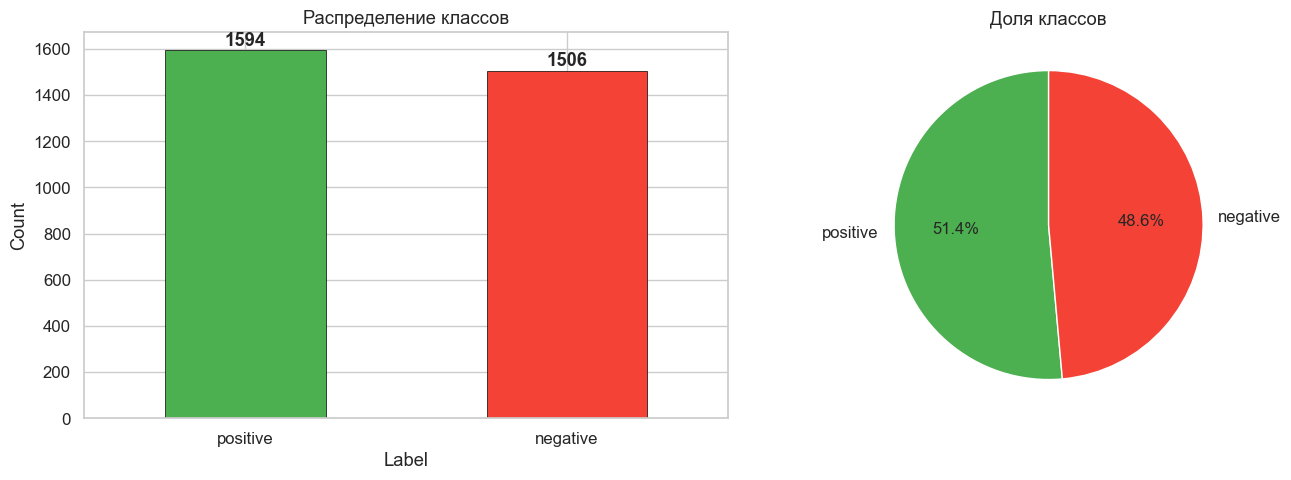

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df["label"].value_counts()
colors = ["#4CAF50", "#F44336"]

counts.plot.bar(ax=axes[0], color=colors, edgecolor="black", linewidth=0.5)
axes[0].set_title("Распределение классов")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(counts):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")

counts.plot.pie(
    ax=axes[1], autopct="%1.1f%%", colors=colors, startangle=90,
    textprops={"fontsize": 12},
)
axes[1].set_ylabel("")
axes[1].set_title("Доля классов")

plt.tight_layout()
plt.show()

## 2. Распределение длин текстов

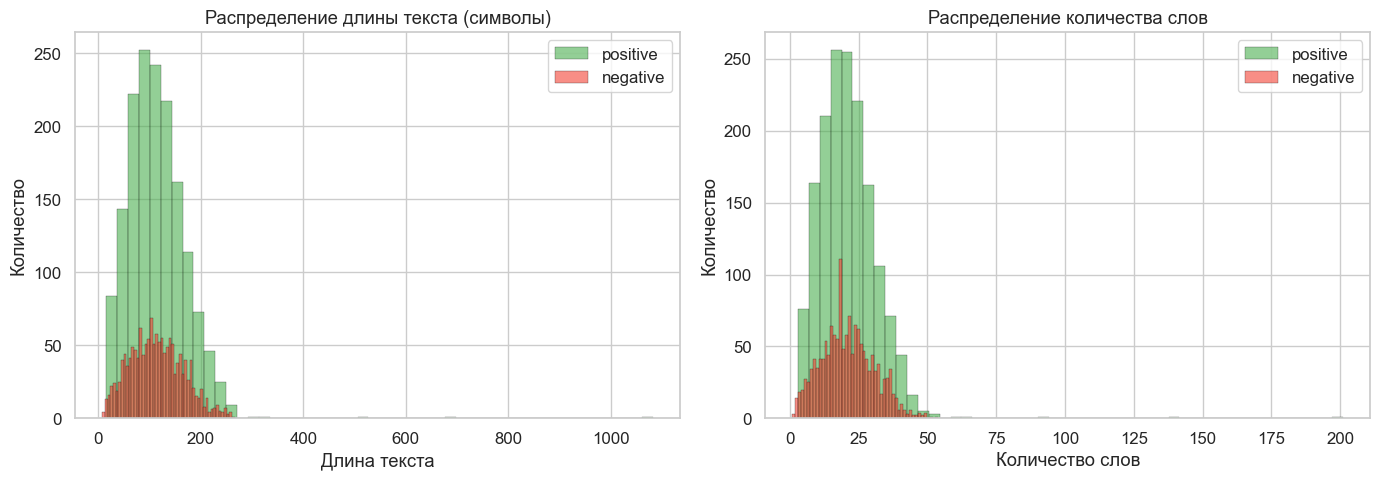

Средняя длина текста: 114 символов
Медиана длины текста: 111 символов
Среднее кол-во слов:  21.0


In [4]:
df["text_len"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color in zip(["positive", "negative"], ["#4CAF50", "#F44336"]):
    subset = df[df["label"] == label]
    axes[0].hist(subset["text_len"], bins=50, alpha=0.6, label=label, color=color, edgecolor="black", linewidth=0.3)
axes[0].set_title("Распределение длины текста (символы)")
axes[0].set_xlabel("Длина текста")
axes[0].set_ylabel("Количество")
axes[0].legend()

for label, color in zip(["positive", "negative"], ["#4CAF50", "#F44336"]):
    subset = df[df["label"] == label]
    axes[1].hist(subset["word_count"], bins=50, alpha=0.6, label=label, color=color, edgecolor="black", linewidth=0.3)
axes[1].set_title("Распределение количества слов")
axes[1].set_xlabel("Количество слов")
axes[1].set_ylabel("Количество")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Средняя длина текста: {df['text_len'].mean():.0f} символов")
print(f"Медиана длины текста: {df['text_len'].median():.0f} символов")
print(f"Среднее кол-во слов:  {df['word_count'].mean():.1f}")

## 3. Топ-20 самых частых слов

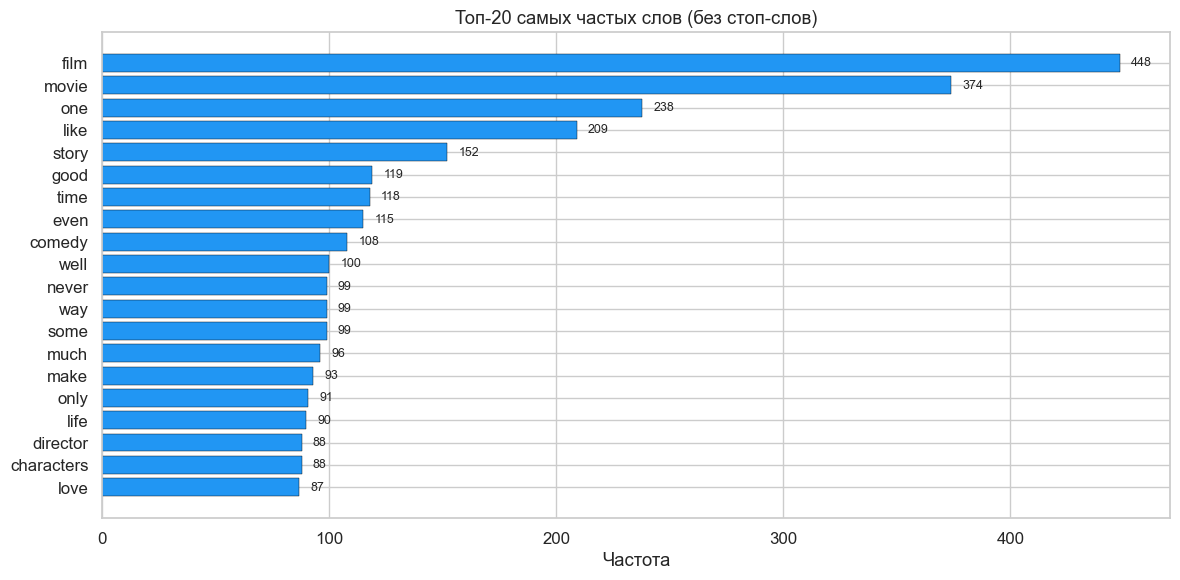

In [5]:
STOP_WORDS = {
    "the", "a", "an", "and", "or", "but", "in", "on", "at", "to", "for",
    "of", "with", "by", "from", "is", "it", "this", "that", "are", "was",
    "be", "as", "has", "have", "had", "not", "no", "do", "does", "did",
    "will", "would", "can", "could", "should", "may", "might", "shall",
    "its", "i", "you", "he", "she", "we", "they", "me", "him", "her",
    "us", "them", "my", "your", "his", "our", "their", "what", "which",
    "who", "whom", "if", "than", "so", "just", "about", "up", "out",
    "all", "been", "being", "there", "here", "when", "where", "how",
    "more", "most", "very", "too", "also", "into", "over", "s", "t",
}

all_words = []
for text in df["text"].dropna():
    tokens = re.findall(r"[a-zA-Z]+", text.lower())
    all_words.extend(w for w in tokens if w not in STOP_WORDS and len(w) > 2)

word_freq = Counter(all_words).most_common(20)
words, freqs = zip(*word_freq)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(list(reversed(words)), list(reversed(freqs)), color="#2196F3", edgecolor="black", linewidth=0.3)
ax.set_title("Топ-20 самых частых слов (без стоп-слов)")
ax.set_xlabel("Частота")
for bar, freq in zip(bars, reversed(freqs)):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2, str(freq), va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 4. Облако слов (Word Cloud)

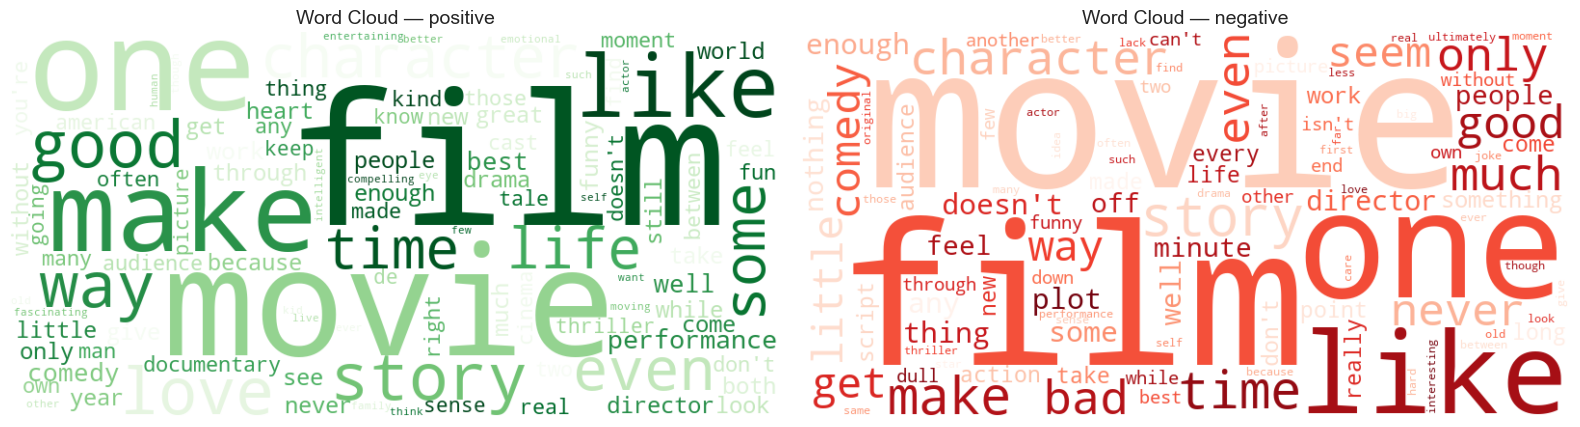

In [6]:
try:
    from wordcloud import WordCloud

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, label, cmap in zip(axes, ["positive", "negative"], ["Greens", "Reds"]):
        texts = " ".join(df[df["label"] == label]["text"].dropna())
        wc = WordCloud(
            width=800, height=400,
            background_color="white",
            colormap=cmap,
            max_words=100,
            stopwords=STOP_WORDS,
        ).generate(texts)
        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(f"Word Cloud — {label}", fontsize=14)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
except ImportError:
    print("wordcloud не установлен — pip install wordcloud")

## 5. Распределение по источникам

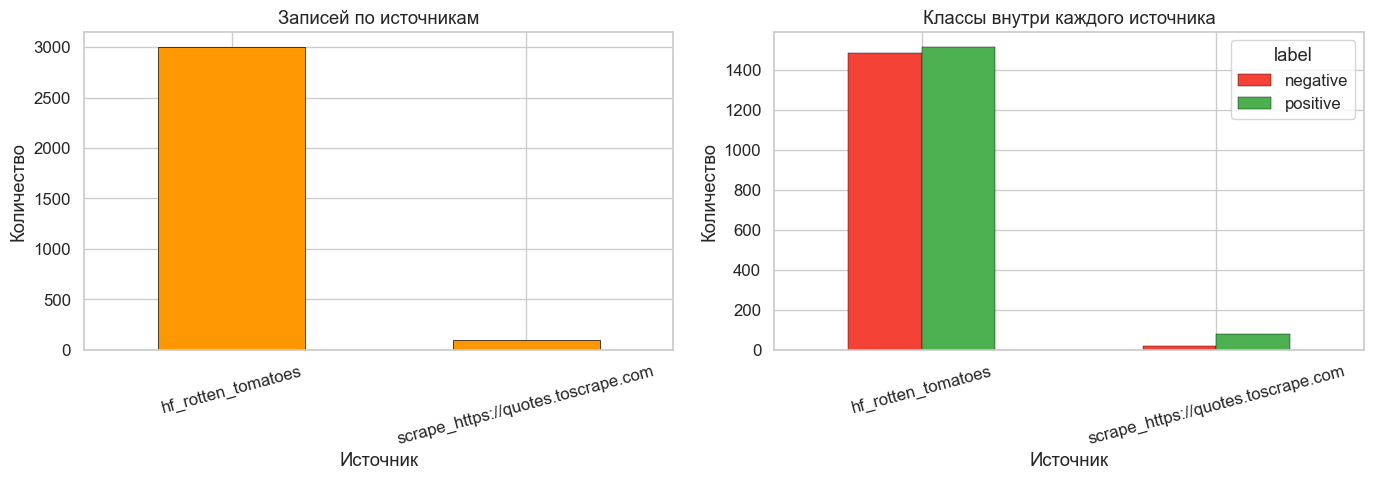

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

source_counts = df["source"].value_counts()
source_counts.plot.bar(ax=axes[0], color="#FF9800", edgecolor="black", linewidth=0.5)
axes[0].set_title("Записей по источникам")
axes[0].set_xlabel("Источник")
axes[0].set_ylabel("Количество")
axes[0].tick_params(axis="x", rotation=15)

cross = pd.crosstab(df["source"], df["label"])
cross.plot.bar(ax=axes[1], color=["#F44336", "#4CAF50"], edgecolor="black", linewidth=0.3)
axes[1].set_title("Классы внутри каждого источника")
axes[1].set_xlabel("Источник")
axes[1].set_ylabel("Количество")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(title="label")

plt.tight_layout()
plt.show()

## 6. Сводная таблица

In [8]:
summary = (
    df.groupby("source")
    .agg(
        records=("text", "count"),
        positive=("label", lambda x: (x == "positive").sum()),
        negative=("label", lambda x: (x == "negative").sum()),
        avg_text_len=("text_len", "mean"),
        avg_word_count=("word_count", "mean"),
    )
    .round(1)
)
summary["balance (pos%)"] = (summary["positive"] / summary["records"] * 100).round(1)
print("Сводная статистика по источникам:\n")
display(summary)

print(f"\nВсего записей: {len(df)}")
print(f"Positive: {(df['label'] == 'positive').sum()}  |  Negative: {(df['label'] == 'negative').sum()}")

Сводная статистика по источникам:



,records,positive,negative,avg_text_len,avg_word_count,balance (pos%)
source,,,,,,
hf_rotten_tomatoes,3000,1514,1486,114.1,20.9,50.5
scrape_https://quotes.toscrape.com,100,80,20,120.3,23.6,80.0



Всего записей: 3100
Positive: 1594  |  Negative: 1506
